In [2]:
import pandas as pd 
import numpy as np
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Stock Price Data

In [5]:
# collection of stock price data
import yfinance as yf

ticker = "BBRI.JK"  
stock = yf.download(ticker, start="2019-01-01", end="2025-01-31")

stock.to_csv("BBRI_historical.csv")
stock 


In [2]:
stock = pd.read_csv('BBRI_historical.csv')
stock

,Price,Close,High,Low,Open,Volume
0,Ticker,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK
1,Date,NaN,NaN,NaN,NaN,NaN
2,2019-01-01,2372.93701171875,2372.93701171875,2372.93701171875,2372.93701171875,0
3,2019-01-02,2340.519775390625,2359.9700502584606,2327.552983518293,2340.519775390625,82441033
4,2019-01-03,2347.00341796875,2359.9702107227486,2321.0696583420654,2321.0696583420654,102805905
...,...,...,...,...,...,...
1484,2025-01-21,4026.37255859375,4139.79150390625,4016.9209798177085,4035.824137369792,345223800
1485,2025-01-22,4026.37255859375,4083.08203125,3998.017822265625,4073.6304524739585,193218900
1486,2025-01-23,4064.178955078125,4101.985270939317,4026.3726392169333,4026.3726392169333,216018100
1487,2025-01-24,3960.21142578125,4111.436683090319,3960.21142578125,4111.436683090319,276421900


In [3]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1489 entries, 0 to 1488
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1489 non-null   object
 1   Close   1488 non-null   object
 2   High    1488 non-null   object
 3   Low     1488 non-null   object
 4   Open    1488 non-null   object
 5   Volume  1488 non-null   object
dtypes: object(6)
memory usage: 69.9+ KB


In [4]:
stock = stock.drop([0,1])
stock = stock.rename(columns={"Price": "Date", "Close":"Stock Price", "High":"Stock High",
                              "Low":"Stock Low", "Open":"Stock Open"})
stock = stock.drop(columns=['Volume'])

# Konversi kolom tertentu ke float
stock["Stock Open"] = stock["Stock Open"].astype(float)
stock["Stock Price"] = stock["Stock Price"].astype(float)
stock["Stock Low"] = stock["Stock Low"].astype(float)
stock["Stock High"] = stock["Stock High"].astype(float)
stock['Date'] = pd.to_datetime(stock['Date'])  # Konversi ke datetime

stock

,Date,Stock Price,Stock High,Stock Low,Stock Open
2,2019-01-01,2372.937012,2372.937012,2372.937012,2372.937012
3,2019-01-02,2340.519775,2359.970050,2327.552984,2340.519775
4,2019-01-03,2347.003418,2359.970211,2321.069658,2321.069658
5,2019-01-04,2372.937012,2372.937012,2340.519771,2347.003254
6,2019-01-07,2372.937012,2405.354078,2372.937012,2398.870770
...,...,...,...,...,...
1484,2025-01-21,4026.372559,4139.791504,4016.920980,4035.824137
1485,2025-01-22,4026.372559,4083.082031,3998.017822,4073.630452
1486,2025-01-23,4064.178955,4101.985271,4026.372639,4026.372639
1487,2025-01-24,3960.211426,4111.436683,3960.211426,4111.436683


In [6]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1487 entries, 2 to 1488
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         1487 non-null   datetime64[ns]
 1   Stock Price  1487 non-null   float64       
 2   Stock High   1487 non-null   float64       
 3   Stock Low    1487 non-null   float64       
 4   Stock Open   1487 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 58.2 KB


In [7]:
stock.isna().sum()

Date           0
Stock Price    0
Stock High     0
Stock Low      0
Stock Open     0
dtype: int64

In [8]:
import plotly.express as px

fig = px.line(stock, x='Date', y='Stock Price', title='BBRI Stock Price 2019 - 2025', markers = True)
fig.show()

C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  v = v.dt.to_pydatetime()


In [9]:
fig = px.line(stock, x='Date', y='Stock High', title='High Price per Day', markers= True)
fig.show()

C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [10]:
fig = px.line(stock, x='Date', y='Stock Low', title='Low Price per Day', markers= True)
fig.show()

C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [11]:
fig = px.line(stock, x='Date', y='Stock Open', title='Open Price per Day', markers= True)
fig.show()

C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [28]:
stock.duplicated().sum()

0

In [29]:
numeric_df = stock.select_dtypes(include='number')
numeric_df.describe()

,Stock Price,Stock High,Stock Low,Stock Open
count,1487.000000,1487.000000,1487.000000,1487.000000
mean,3475.921171,3516.787986,3439.950224,3479.735783
std,879.517319,883.581157,875.258970,877.473019
min,1513.756958,1583.515397,1506.781067,1569.563616
25%,2807.621338,2833.278380,2775.646850,2813.136425
50%,3327.475098,3363.488599,3299.572210,3334.450975
75%,4097.961060,4141.867529,4047.891774,4102.534924
max,5763.100098,5785.969664,5694.491883,5763.100219


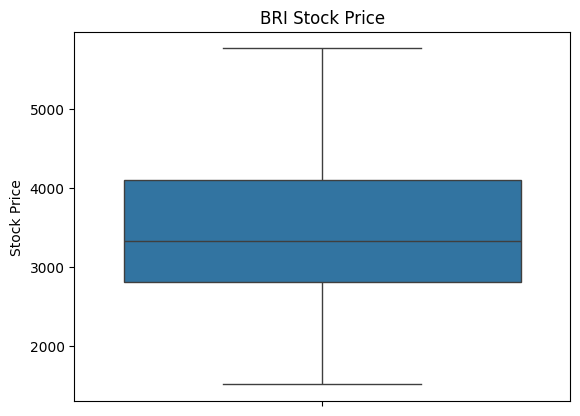

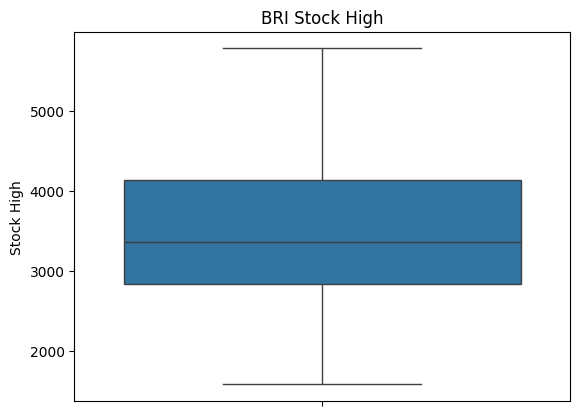

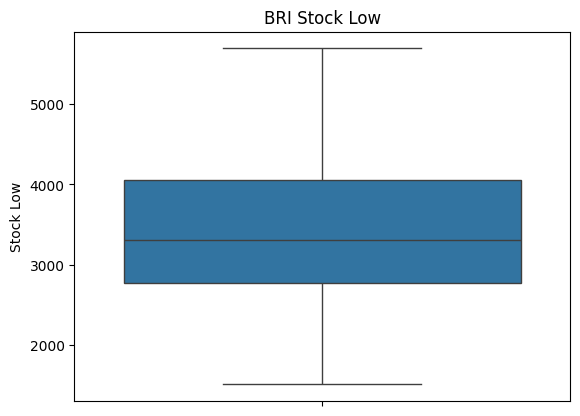

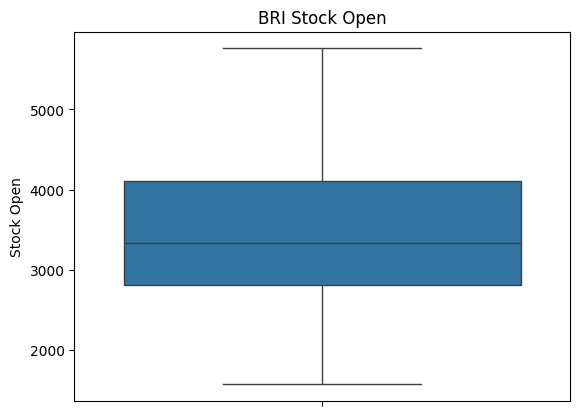

In [30]:
for i in numeric_df :
    sns.boxplot(numeric_df[i])
    plt.title('BRI '+i)
    plt.show()
    

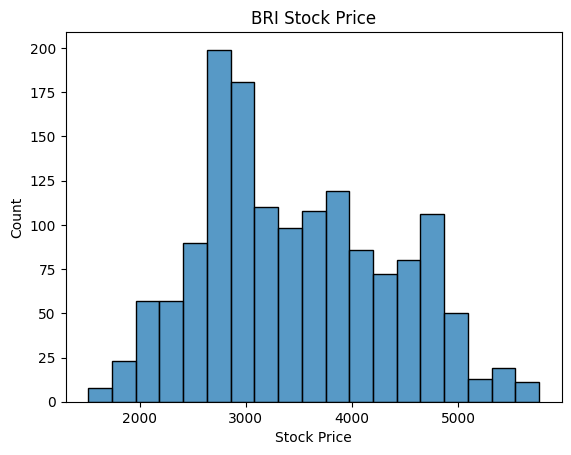

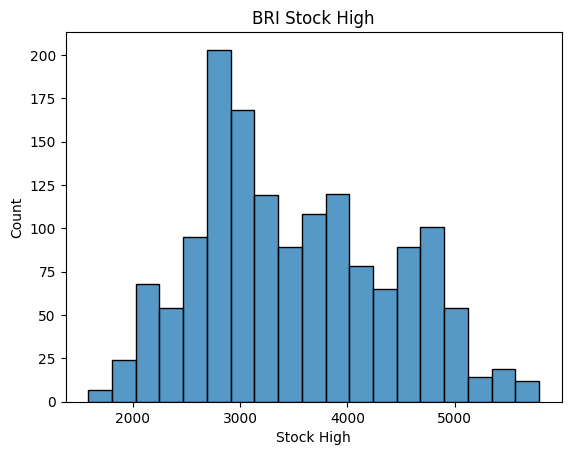

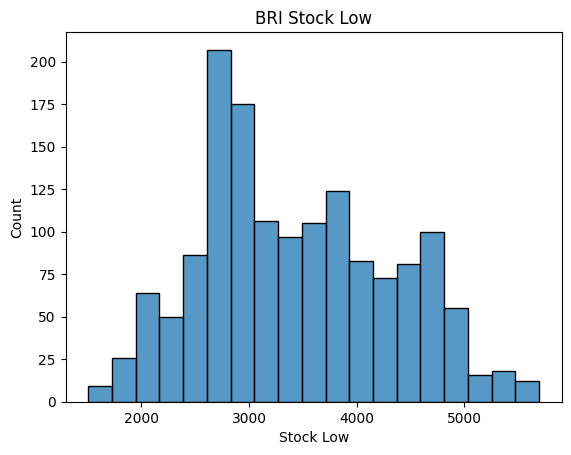

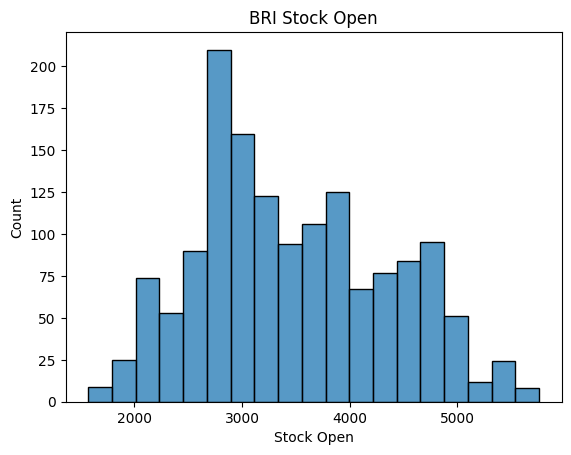

In [31]:
for i in numeric_df :
    sns.histplot(numeric_df[i])
    plt.title('BRI '+ i)
    plt.show()

# Inflation

In [3]:
inflasi = pd.read_excel ('Data Inflasi.xlsx')
inflasi

,No,Periode,Data Inflasi
0,1,Januari 2025,0.76 %
1,2,Desember 2024,1.57 %
2,3,November 2024,1.55 %
3,4,Oktober 2024,1.71 %
4,5,September 2024,1.84 %
...,...,...,...
68,69,Mei 2019,3.32 %
69,70,April 2019,2.83 %
70,71,Maret 2019,2.48 %
71,72,Februari 2019,2.57 %


In [4]:
inflasi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   No            73 non-null     int64 
 1   Periode       73 non-null     object
 2   Data Inflasi  73 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.8+ KB


In [5]:
inflasi.rename(columns={'Periode' : 'Date', 
                                 'Data Inflasi' : 'Inflasi'},inplace=True)

inflasi = inflasi.drop(columns=['No'])

# Mapping nama bulan Indonesia ke Inggris
month_mapping = {
    'Januari': 'January', 'Februari': 'February', 'Maret': 'March',
    'April': 'April', 'Mei': 'May', 'Juni': 'June',
    'Juli': 'July', 'Agustus': 'August', 'September': 'September',
    'Oktober': 'October', 'November': 'November', 'Desember': 'December'
}

# Mengganti nama bulan ke bahasa Inggris
inflasi['Date'] = inflasi['Date'].replace(month_mapping, regex=True)

# Konversi ke format datetime (defaultnya YYYY-MM-DD dengan tanggal 1)
inflasi['Date'] = pd.to_datetime(inflasi['Date'], format='%B %Y')

# Mengubah format 
inflasi['Inflasi'] = inflasi['Inflasi'].str.replace('%', '').astype(float) / 100

inflasi

,Date,Inflasi
0,2025-01-01,0.0076
1,2024-12-01,0.0157
2,2024-11-01,0.0155
3,2024-10-01,0.0171
4,2024-09-01,0.0184
...,...,...
68,2019-05-01,0.0332
69,2019-04-01,0.0283
70,2019-03-01,0.0248
71,2019-02-01,0.0257


In [36]:
inflasi['Inflasi'] = inflasi['Inflasi'].str.replace('%', '').astype(float) / 100

In [6]:
inflasi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     73 non-null     datetime64[ns]
 1   Inflasi  73 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.3 KB


In [7]:
inflasi[['Inflasi']].describe()

,Inflasi
count,73.000000
mean,0.027753
std,0.012395
min,0.007600
25%,0.016800
50%,0.026400
75%,0.033200
max,0.059500


In [8]:
inflasi.isna().sum()

Date       0
Inflasi    0
dtype: int64

In [9]:
inflasi.duplicated().sum()

0

In [10]:
import plotly.express as px

# Buat line chart interaktif
fig = px.line(inflasi, x='Date', y='Inflasi', title='Inflation', markers=True)
fig.show()


C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  v = v.dt.to_pydatetime()


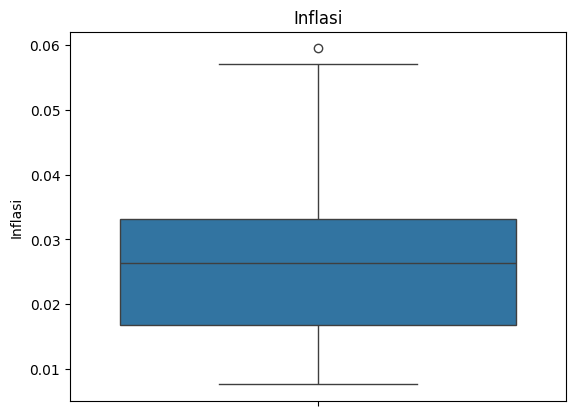

In [11]:
sns.boxplot(inflasi['Inflasi'])
plt.title('Inflasi')
plt.show()

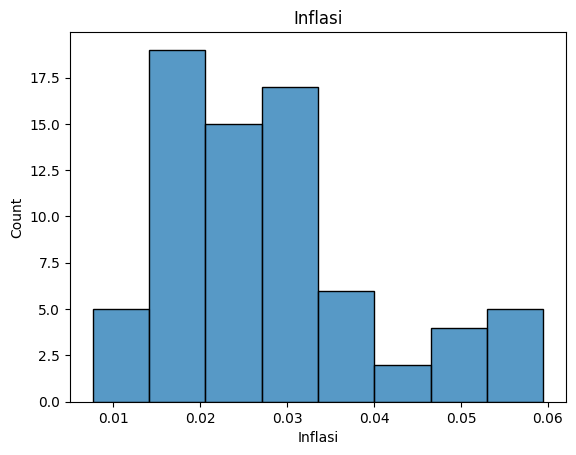

In [12]:
sns.histplot(inflasi['Inflasi'])
plt.title('Inflasi')
plt.show()

# Currency Exchange Data

In [13]:
# Collection of Currency Exchange Data
import yfinance as yf

ticker = "USDIDR=X"  
exchange = yf.download(ticker, start="2019-01-01", end="2025-01-31")

exchange.to_csv("USDIDR_historical.csv")

print(exchange.head())


C:\Users\zakyf\AppData\Local\Temp\ipykernel_22876\1178423829.py:5: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Price              Close     High           Low          Open   Volume
Ticker          USDIDR=X USDIDR=X      USDIDR=X      USDIDR=X USDIDR=X
Date                                                                  
2019-01-01  14460.000000  14460.0  14460.000000  14460.000000        0
2019-01-02  14460.000000  14513.0  14373.000000  14460.000000        0
2019-01-03  14409.700195  14502.5  14367.900391  14409.700195        0
2019-01-04  14375.400391  14403.0  14211.000000  14375.400391        0
2019-01-07  14267.000000  14263.0  14008.000000  14263.000000        0


In [14]:
exchange = pd.read_csv("USDIDR_historical.csv")
exchange

,Price,Close,High,Low,Open,Volume
0,Ticker,USDIDR=X,USDIDR=X,USDIDR=X,USDIDR=X,USDIDR=X
1,Date,NaN,NaN,NaN,NaN,NaN
2,2019-01-01,14460.0,14460.0,14460.0,14460.0,0
3,2019-01-02,14460.0,14513.0,14373.0,14460.0,0
4,2019-01-03,14409.7001953125,14502.5,14367.900390625,14409.7001953125,0
...,...,...,...,...,...,...
1583,2025-01-24,16230.900390625,16234.0,16090.400390625,16230.900390625,0
1584,2025-01-27,16164.900390625,16234.0,16141.0,16164.900390625,0
1585,2025-01-28,16155.599609375,16246.0,16140.099609375,16155.599609375,0
1586,2025-01-29,15881.2001953125,16269.2998046875,15960.599609375,15881.2001953125,0


In [15]:
exchange.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1588 entries, 0 to 1587
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1588 non-null   object
 1   Close   1587 non-null   object
 2   High    1587 non-null   object
 3   Low     1587 non-null   object
 4   Open    1587 non-null   object
 5   Volume  1587 non-null   object
dtypes: object(6)
memory usage: 74.6+ KB


In [16]:
exchange = exchange.drop([0,1])
exchange = exchange.drop(columns=['Volume','High','Low','Open'])
exchange = exchange.rename(columns={'Price' : 'Date', 'Close' : 'Exchange Price'})

exchange["Exchange Price"] = exchange["Exchange Price"].astype(float) # Konversi ke float
exchange['Date'] = pd.to_datetime(exchange['Date'])  # Konversi ke datetime

exchange

,Date,Exchange Price
2,2019-01-01,14460.000000
3,2019-01-02,14460.000000
4,2019-01-03,14409.700195
5,2019-01-04,14375.400391
6,2019-01-07,14267.000000
...,...,...
1583,2025-01-24,16230.900391
1584,2025-01-27,16164.900391
1585,2025-01-28,16155.599609
1586,2025-01-29,15881.200195


In [17]:
import plotly.express as px

# Buat line chart interaktif
fig = px.line(exchange, x='Date', y='Exchange Price', title='Exchange', markers=True)
fig.show()


C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [18]:
exchange.isna().sum()

Date              0
Exchange Price    0
dtype: int64

In [19]:
exchange.duplicated().sum()

0

In [20]:
exchange.dtypes

Date              datetime64[ns]
Exchange Price           float64
dtype: object

In [21]:
exchange.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1586 entries, 2 to 1587
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            1586 non-null   datetime64[ns]
 1   Exchange Price  1586 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 24.9 KB


In [81]:
exchange[['Exchange Price']].describe()

,Exchange Price
count,1586.000000
mean,14837.977412
std,710.574814
min,13213.240234
25%,14251.654297
50%,14652.887207
75%,15449.500000
max,16504.800781


In [23]:
numeric_df = exchange.select_dtypes(include=['number'])
numeric_df

,Exchange Price
2,14460.000000
3,14460.000000
4,14409.700195
5,14375.400391
6,14267.000000
...,...
1583,16230.900391
1584,16164.900391
1585,16155.599609
1586,15881.200195


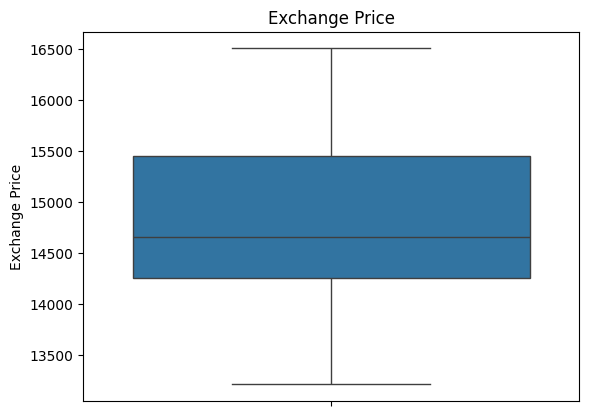

In [24]:
for i in numeric_df :
    sns.boxplot(numeric_df[i])
    plt.title(i)
    plt.show()

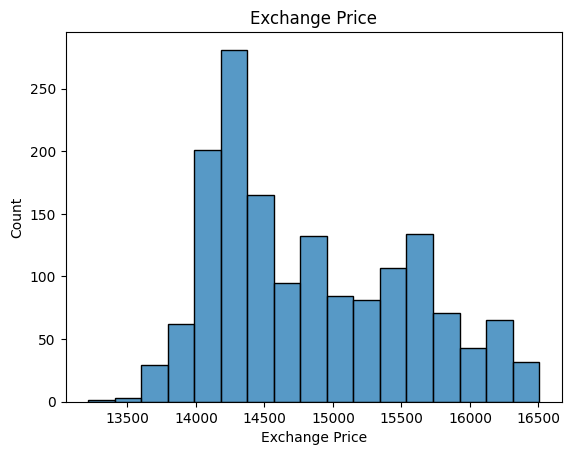

In [25]:
for i in numeric_df:
    sns.histplot(numeric_df[i])
    plt.title(i)
    plt.show()

# Sentiment Analysis

In [69]:
# Lokasi folder
folder_path = "your comments data folder path/*.csv"

# Membaca semua file CSV di folder
all_files = glob.glob(folder_path)
list_df = [pd.read_csv(file) for file in all_files]

# Menggabungkan semua DataFrame menjadi satu
twt = pd.concat(list_df, axis=0, ignore_index=True)
twt

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1862168063837347998,Thu Nov 28 16:13:58 +0000 2024,1,kemeriahan Panen Hadiah Simpedes Semester I br...,1862168063837347998,https://pbs.twimg.com/ext_tw_video_thumb/18621...,NaN,in,"Subang, Indonesia",0,0,0,https://x.com/mheruyudha/status/18621680638373...,3306149840,mheruyudha
1,1874088644874821953,Tue Dec 31 13:42:06 +0000 2024,1,Jual cepat ruko 2 5 lantai sederet kantor Bank...,1874088644874821953,https://pbs.twimg.com/ext_tw_video_thumb/18740...,NaN,in,"ÜT: -6.268709,106.96718",0,0,0,https://x.com/elrachman/status/187408864487482...,108183306,elrachman
2,1873591587080679604,Mon Dec 30 04:46:58 +0000 2024,0,Apakah Bank BRI akan bangkrut? #bankbri #saham...,1873591587080679604,https://pbs.twimg.com/ext_tw_video_thumb/18735...,NaN,in,"Jakarta Selatan, DKI Jakarta",0,0,0,https://x.com/SukatendelRuben/status/187359158...,4210913724,SukatendelRuben
3,1863460236692193454,Mon Dec 02 05:48:36 +0000 2024,0,Karikatur konsep My Trip My adventure #OFFRoad...,1863460236692193454,https://pbs.twimg.com/media/GdxXNdKbMAAvBLy.jpg,NaN,en,NaN,0,0,0,https://x.com/KarikaturLucu/status/18634602366...,1277209578,KarikaturLucu
4,1858520322028494925,Mon Nov 18 14:39:09 +0000 2024,12,Yang pake BRI Mobile aka Brimo ada yang error ...,1858520322028494925,NaN,NaN,in,NaN,0,27,0,https://x.com/hereissaf/status/185852032202849...,1426765819451633669,hereissaf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4794,1777680228728684964,Tue Apr 09 12:49:28 +0000 2024,731,Tarikh 1 Syawal di rantau ini: Brunei - Khamis...,1777680228728684964,NaN,NaN,in,NaN,12,7,210,https://x.com/undefined/status/177768022872868...,328045907,NaN
4795,1881949379659218979,Wed Jan 22 06:17:51 +0000 2025,0,Sunarso Borong Saham BRI Ternyata Ini Alasanny...,1881949379659218979,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/188194937965921...,606096303,NaN
4796,1879426157923430827,Wed Jan 15 07:11:28 +0000 2025,0,Bayarkan Dividen Interim Rp20 33 Triliun Komit...,1879426157923430827,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/187942615792343...,2422855764,NaN
4797,1086471982361632769,Sat Jan 19 03:54:40 +0000 2019,565,Dulu BR1M sekarang namanya Bantuan Sara Hidup ...,1086471982361632769,https://pbs.twimg.com/media/DxPsgEuUYAAwkim.jpg,NaN,in,NaN,5,1,454,https://x.com/undefined/status/108647198236163...,3257463756,NaN


In [70]:
twt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4799 entries, 0 to 4798
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   conversation_id_str      4799 non-null   int64 
 1   created_at               4799 non-null   object
 2   favorite_count           4799 non-null   int64 
 3   full_text                4797 non-null   object
 4   id_str                   4799 non-null   int64 
 5   image_url                2416 non-null   object
 6   in_reply_to_screen_name  506 non-null    object
 7   lang                     4799 non-null   object
 8   location                 1868 non-null   object
 9   quote_count              4799 non-null   int64 
 10  reply_count              4799 non-null   int64 
 11  retweet_count            4799 non-null   int64 
 12  tweet_url                4799 non-null   object
 13  user_id_str              4799 non-null   int64 
 14  username                 2496 non-null  

In [71]:
twt['Date'] = pd.to_datetime(twt['created_at'], format='%a %b %d %H:%M:%S %z %Y').dt.strftime('%Y-%m-%d')
twt['Date'] = pd.to_datetime(twt['Date'])
twt = twt[['Date', 'id_str','full_text']]
twt

,Date,id_str,full_text
0,2024-11-28,1862168063837347998,kemeriahan Panen Hadiah Simpedes Semester I br...
1,2024-12-31,1874088644874821953,Jual cepat ruko 2 5 lantai sederet kantor Bank...
2,2024-12-30,1873591587080679604,Apakah Bank BRI akan bangkrut? #bankbri #saham...
3,2024-12-02,1863460236692193454,Karikatur konsep My Trip My adventure #OFFRoad...
4,2024-11-18,1858520322028494925,Yang pake BRI Mobile aka Brimo ada yang error ...
...,...,...,...
4794,2024-04-09,1777680228728684964,Tarikh 1 Syawal di rantau ini: Brunei - Khamis...
4795,2025-01-22,1881949379659218979,Sunarso Borong Saham BRI Ternyata Ini Alasanny...
4796,2025-01-15,1879426157923430827,Bayarkan Dividen Interim Rp20 33 Triliun Komit...
4797,2019-01-19,1086471982361632769,Dulu BR1M sekarang namanya Bantuan Sara Hidup ...


In [72]:
twt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4799 entries, 0 to 4798
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4799 non-null   datetime64[ns]
 1   id_str     4799 non-null   int64         
 2   full_text  4797 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 112.6+ KB


In [73]:
twt.isna().sum()

Date         0
id_str       0
full_text    2
dtype: int64

In [74]:
twt.duplicated().sum()

1771

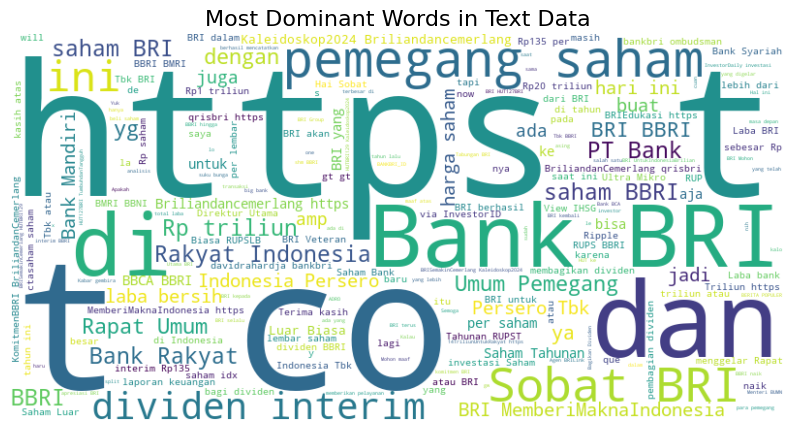

In [53]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(twt['full_text'].astype(str))  # gabungkan semua teks jadi satu string
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Dominant Words in Text Data', fontsize=16)
plt.show()


In [54]:
# Preprocessing

twt = twt.drop_duplicates(subset=['id_str'])
twt.duplicated().sum()

,Date,id_str,full_text
0,2024-11-28,1862168063837347998,kemeriahan Panen Hadiah Simpedes Semester I br...
1,2024-12-31,1874088644874821953,Jual cepat ruko 2 5 lantai sederet kantor Bank...
2,2024-12-30,1873591587080679604,Apakah Bank BRI akan bangkrut? #bankbri #saham...
3,2024-12-02,1863460236692193454,Karikatur konsep My Trip My adventure #OFFRoad...
4,2024-11-18,1858520322028494925,Yang pake BRI Mobile aka Brimo ada yang error ...
...,...,...,...
4789,2019-06-13,1139090930806321152,Alhamdulillah... Takbir.... Allahu Akbar Allah...
4790,2021-06-12,1403596670906945536,Sesungguhnya Ga perlu-perlu amat sih tapi bagu...
4791,2019-01-11,1083722290271940609,Brgsiapa menggantungkan dirinya dgn Allah ia p...
4797,2019-01-19,1086471982361632769,Dulu BR1M sekarang namanya Bantuan Sara Hidup ...


In [55]:
twt = twt.sort_values('Date', ascending = True)
twt

,Date,id_str,full_text
3466,2019-01-04,1081105721280802818,RPSLB Bank BRI: ECONOMIC ZONE - Direktur Utama...
2932,2019-01-07,1082075169877721088,Mal. Utang BUMN itu ada penjelasannya ya. http...
3673,2019-01-08,1082655729113280513,Could Ripple's XRP replace correspondent banks...
4791,2019-01-11,1083722290271940609,Brgsiapa menggantungkan dirinya dgn Allah ia p...
4797,2019-01-19,1086471982361632769,Dulu BR1M sekarang namanya Bantuan Sara Hidup ...
...,...,...,...
2956,2025-01-26,1883424832471113763,Jends! mau tanya sender kan terhambat pembayar...
2217,2025-01-29,1884572891485966505,Deposito BPR Deposito yg BERANI ngasih bunga 6...
2047,2025-01-29,1884444363700461649,Bos BRI Beli Saham Pakai Dividen! Pak Sunarso...
2272,2025-01-30,1884999640942350711,BRI Setor Rp98 4 Triliun ke Negara! Sahamnya ...


In [56]:
teks = twt[['Date','full_text']]
teks = teks.dropna(subset=['full_text'])
teks

,Date,full_text
3466,2019-01-04,RPSLB Bank BRI: ECONOMIC ZONE - Direktur Utama...
2932,2019-01-07,Mal. Utang BUMN itu ada penjelasannya ya. http...
3673,2019-01-08,Could Ripple's XRP replace correspondent banks...
4791,2019-01-11,Brgsiapa menggantungkan dirinya dgn Allah ia p...
4797,2019-01-19,Dulu BR1M sekarang namanya Bantuan Sara Hidup ...
...,...,...
2956,2025-01-26,Jends! mau tanya sender kan terhambat pembayar...
2217,2025-01-29,Deposito BPR Deposito yg BERANI ngasih bunga 6...
2047,2025-01-29,Bos BRI Beli Saham Pakai Dividen! Pak Sunarso...
2272,2025-01-30,BRI Setor Rp98 4 Triliun ke Negara! Sahamnya ...


In [57]:
#Preprocessing full text
import string
import re


def remove_single_char_words(text):
    # Pisahkan teks menjadi kata-kata
    words = text.split()
    # Hanya pertahankan kata yang panjangnya lebih dari 1 karakter
    filtered_words = [word for word in words if len(word) > 3]
    # Gabungkan kembali menjadi satu string
    return ' '.join(filtered_words)


def filteringText(text):
    if text is None:  # Check if the input is None
        return ''  # Return empty string if it is None

    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = text.replace('\n', ' ')
    text = remove_single_char_words(text)
    text = text.strip(' ')

    return text


data_slang = pd.read_excel('kamus_slangword.xlsx')
def replace_slang(text):
    res = ''
    for item in text.split():
        if item in data_slang.slang.values:
            res += data_slang[data_slang['slang'] == item]['formal'].iloc[0]
        else:
            res += item
        res += ' '
    return res


In [59]:
#fix slangwords
teks['full_text'] = teks['full_text'].apply(replace_slang)
teks

,Date,full_text
3466,2019-01-04,RPSLB Bank BRI: ECONOMIC ZONE - Direktur Utama...
2932,2019-01-07,Mal. Utang BUMN itu ada penjelasannya ya. http...
3673,2019-01-08,Could Ripple's XRP replace correspondent banks...
4791,2019-01-11,Brgsiapa menggantungkan dirinya dengan Allah i...
4797,2019-01-19,Dulu BR1M sekarang namanya Bantuan Sara Hidup ...
...,...,...
2956,2025-01-26,Jends! mau tanya sender kan terhambat pembayar...
2217,2025-01-29,Deposito BPR Deposito yang BERANI mengasih bun...
2047,2025-01-29,Bos BRI Beli Saham Pakai Dividen! Pak Sunarso ...
2272,2025-01-30,BRI Setor Rp98 4 Triliun ke Negara! Sahamnya m...


In [60]:
#filtering
teks['full_text'] = teks['full_text'].apply(filteringText)
teks

,Date,full_text
3466,2019-01-04,RPSLB Bank BRI: ECONOMIC ZONE Direktur Utama B...
2932,2019-01-07,Mal. Utang BUMN penjelasannya misalnya. Rp1.00...
3673,2019-01-08,Could Ripple's replace correspondent banks? Th...
4791,2019-01-11,Brgsiapa menggantungkan dirinya dengan Allah p...
4797,2019-01-19,Dulu BR1M sekarang namanya Bantuan Sara Hidup ...
...,...,...
2956,2025-01-26,Jends! tanya sender terhambat pembayaran melal...
2217,2025-01-29,Deposito Deposito yang BERANI mengasih bunga t...
2047,2025-01-29,Beli Saham Pakai Dividen! Sunarso Direktur Uta...
2272,2025-01-30,Setor Rp98 Triliun Negara! Sahamnya makin mena...


In [ ]:
from deep_translator import GoogleTranslator
import pandas as pd

# Inisialisasi Google Translator
translator = GoogleTranslator(source='auto', target='en')

# Fungsi untuk menerjemahkan teks
def translate_text(text):
    if pd.isna(text):  # Jika cell kosong, lewati
        return ""
    return translator.translate(text)

# Terapkan fungsi translate ke kolom 'full_text'
teks['full_text'] = teks['full_text'].apply(translate_text)

# Menampilkan hasil
teks


In [53]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import unicodedata

sentiment_i_a = SentimentIntensityAnalyzer()

# Iterate over rows of the original dataframe, not the transposed version
for indexx, row in teks.iterrows():
    try:
        sentence_i = unicodedata.normalize('NFKD', row['full_text'])
        sentence_sentiment = sentiment_i_a.polarity_scores(sentence_i)
        
        # Update the dataframe with sentiment scores
        teks.at[indexx, 'Comp'] = sentence_sentiment['compound']
        teks.at[indexx, 'Negative'] = sentence_sentiment['neg']
        teks.at[indexx, 'Neutral'] = sentence_sentiment['neu']
        teks.at[indexx, 'Positive'] = sentence_sentiment['pos']
    except TypeError:
        print(teks.loc[indexx, 'full_text'])
        print(indexx)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\zakyf\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [54]:
import pandas as pd

teks['Date'] = pd.to_datetime(teks['Date'])

# Agregasi berdasarkan tanggal
aggregated_data = teks.groupby('Date').agg(
    mean_comp=('Comp', 'mean'),   # Rata=rata skor compound
    median_comp=('Comp', 'median'),       # Median Comp
    mean_negative=('Negative', 'mean'),  # Rata-rata Negative
    mean_neutral=('Neutral', 'mean'),    # Rata-rata Neutral
    mean_positive=('Positive', 'mean')   # Rata-rata Positive
).reset_index()

# Menampilkan hasil agregasi
aggregated_data


,Date,mean_comp,median_comp,mean_negative,mean_neutral,mean_positive
0,2019-01-04,0.000000,0.00000,0.00000,1.000000,0.0000
1,2019-01-07,0.143100,0.14310,0.08200,0.818000,0.1000
2,2019-01-08,0.000000,0.00000,0.00000,1.000000,0.0000
3,2019-01-11,0.595600,0.59560,0.08500,0.761000,0.1540
4,2019-01-19,0.509350,0.50935,0.00000,0.850500,0.1495
...,...,...,...,...,...,...
1064,2025-01-24,0.304262,0.50170,0.12075,0.722625,0.1565
1065,2025-01-25,0.478560,0.54730,0.03340,0.771000,0.1956
1066,2025-01-26,0.584800,0.58480,0.02300,0.879000,0.0980
1067,2025-01-29,0.895150,0.89515,0.00000,0.750500,0.2495


In [55]:
aggregated_data.to_csv('sentiment score bri')

In [82]:
aggregated_data = pd.read_csv('sentiment score bri')
aggregated_data = aggregated_data.drop(columns=['Unnamed: 0','median_comp','mean_negative','mean_neutral','mean_positive'])
aggregated_data = aggregated_data.dropna()
aggregated_data

,Date,mean_comp
0,2019-01-04,0.000000
1,2019-01-07,0.143100
2,2019-01-08,0.000000
3,2019-01-11,0.595600
4,2019-01-19,0.509350
...,...,...
1064,2025-01-24,0.304262
1065,2025-01-25,0.478560
1066,2025-01-26,0.584800
1067,2025-01-29,0.895150


In [ ]:
aggregated_data.info()

In [83]:
aggregated_data['Date'] = pd.to_datetime(aggregated_data['Date'])


In [84]:
aggregated_data = aggregated_data.drop(columns=['median_comp','mean_negative',
                                                'mean_neutral','mean_positive'])
df = aggregated_data
for df_merged in [inflasi, exchange, stock]:
    df = pd.merge(df_merged, df, on="Date", how="outer")

df

,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Inflasi,mean_comp
0,2019-01-01,2372.937012,2372.937012,2372.937012,2372.937012,14460.000000,0.0282,NaN
1,2019-01-02,2340.519775,2359.970050,2327.552984,2340.519775,14460.000000,NaN,NaN
2,2019-01-03,2347.003418,2359.970211,2321.069658,2321.069658,14409.700195,NaN,NaN
3,2019-01-04,2372.937012,2372.937012,2340.519771,2347.003254,14375.400391,NaN,0.00000
4,2019-01-07,2372.937012,2405.354078,2372.937012,2398.870770,14267.000000,NaN,0.14310
...,...,...,...,...,...,...,...,...
1834,2025-01-26,NaN,NaN,NaN,NaN,NaN,NaN,0.58480
1835,2025-01-27,NaN,NaN,NaN,NaN,16164.900391,NaN,NaN
1836,2025-01-28,NaN,NaN,NaN,NaN,16155.599609,NaN,NaN
1837,2025-01-29,NaN,NaN,NaN,NaN,15881.200195,NaN,0.89515


In [85]:
# # Mengisi missing value pada data tipe data float atau integer tepat dengan value sebelumnya.
df['Inflasi'] = df['Inflasi'].fillna(method='ffill')
df[['Stock Price','Stock Open','Stock High','Stock Low']] = df[['Stock Price','Stock Open','Stock High','Stock Low']].fillna(method='ffill')
df['Exchange Price'] = df['Exchange Price'].fillna(method='ffill')
df['mean_comp'] = df['mean_comp'].fillna(method='ffill')

C:\Users\zakyf\AppData\Local\Temp\ipykernel_26344\3548278729.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Inflasi'] = df['Inflasi'].fillna(method='ffill')
C:\Users\zakyf\AppData\Local\Temp\ipykernel_26344\3548278729.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[['Stock Price','Stock Open','Stock High','Stock Low']] = df[['Stock Price','Stock Open','Stock High','Stock Low']].fillna(method='ffill')
C:\Users\zakyf\AppData\Local\Temp\ipykernel_26344\3548278729.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Exchange Price'] = df['Exchange Price'].fillna(method='ffill')
C:\Users\zakyf\AppData\Local\Temp\ipykernel_26344\3548278729.py:5: FutureWarning: Series.fillna with 'method' is deprecated and wi

In [86]:
df = df.dropna()
df

,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Inflasi,mean_comp
3,2019-01-04,2372.937012,2372.937012,2340.519771,2347.003254,14375.400391,0.0282,0.00000
4,2019-01-07,2372.937012,2405.354078,2372.937012,2398.870770,14267.000000,0.0282,0.14310
5,2019-01-08,2385.904053,2385.904053,2353.486983,2372.937260,14083.000000,0.0282,0.00000
6,2019-01-09,2411.837646,2424.804439,2392.387371,2405.354163,14138.000000,0.0282,0.00000
7,2019-01-10,2431.287842,2431.287842,2405.354084,2424.804359,14130.000000,0.0282,0.00000
...,...,...,...,...,...,...,...,...
1834,2025-01-26,3960.211426,4111.436683,3960.211426,4111.436683,16230.900391,0.0076,0.58480
1835,2025-01-27,3960.211426,4111.436683,3960.211426,4111.436683,16164.900391,0.0076,0.58480
1836,2025-01-28,3960.211426,4111.436683,3960.211426,4111.436683,16155.599609,0.0076,0.58480
1837,2025-01-29,3960.211426,4111.436683,3960.211426,4111.436683,15881.200195,0.0076,0.89515


In [ ]:
df.duplicated().sum()

In [62]:
df.to_csv('data_BBRI.csv')

In [2]:
df = pd.read_csv('data_BBRI.csv')
df

,Unnamed: 0,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Exchange High,Exchange Low,Exchange Open,Inflasi,mean_comp
0,3,2019-01-04,2372.937012,2372.937012,2340.519771,2347.003254,14375.400391,14403.000000,14211.000000,14375.400391,0.0282,0.00000
1,4,2019-01-07,2372.937012,2405.354078,2372.937012,2398.870770,14267.000000,14263.000000,14008.000000,14263.000000,0.0282,0.14310
2,5,2019-01-08,2385.904053,2385.904053,2353.486983,2372.937260,14083.000000,14164.000000,13988.000000,14094.000000,0.0282,0.00000
3,6,2019-01-09,2411.837646,2424.804439,2392.387371,2405.354163,14138.000000,14192.500000,14058.000000,14145.000000,0.0282,0.00000
4,7,2019-01-10,2431.287842,2431.287842,2405.354084,2424.804359,14130.000000,14130.000000,14008.000000,14130.000000,0.0282,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...
1831,3791,2025-01-26,3960.211426,4111.436683,3960.211426,4111.436683,16230.900391,16234.000000,16090.400391,16230.900391,0.0076,0.58480
1832,3792,2025-01-27,3960.211426,4111.436683,3960.211426,4111.436683,16164.900391,16234.000000,16141.000000,16164.900391,0.0076,0.58480
1833,3793,2025-01-28,3960.211426,4111.436683,3960.211426,4111.436683,16155.599609,16246.000000,16140.099609,16155.599609,0.0076,0.58480
1834,3794,2025-01-29,3960.211426,4111.436683,3960.211426,4111.436683,15881.200195,16269.299805,15960.599609,15881.200195,0.0076,0.89515


# LSTM

In [38]:
import pandas as pd
import numpy as np
import matplotlib
import glob
import re
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten, LSTM
from keras.optimizers import Adam

In [81]:
df = pd.read_csv('data_BBRI.csv')
df = df.drop(columns=['Unnamed: 0'])
df

,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Inflasi,mean_comp
0,2019-01-04,2372.937012,2372.937012,2340.519771,2347.003254,14375.400391,0.0282,0.00000
1,2019-01-07,2372.937012,2405.354078,2372.937012,2398.870770,14267.000000,0.0282,0.14310
2,2019-01-08,2385.904053,2385.904053,2353.486983,2372.937260,14083.000000,0.0282,0.00000
3,2019-01-09,2411.837646,2424.804439,2392.387371,2405.354163,14138.000000,0.0282,0.00000
4,2019-01-10,2431.287842,2431.287842,2405.354084,2424.804359,14130.000000,0.0282,0.00000
...,...,...,...,...,...,...,...,...
1831,2025-01-26,3960.211426,4111.436683,3960.211426,4111.436683,16230.900391,0.0076,0.58480
1832,2025-01-27,3960.211426,4111.436683,3960.211426,4111.436683,16164.900391,0.0076,0.58480
1833,2025-01-28,3960.211426,4111.436683,3960.211426,4111.436683,16155.599609,0.0076,0.58480
1834,2025-01-29,3960.211426,4111.436683,3960.211426,4111.436683,15881.200195,0.0076,0.89515


In [28]:
import plotly.express as px

# Buat line chart interaktif
fig = px.line(df, x='Date', y='Stock Price', title='Stock Price Over Time', markers=True)
fig.show()


In [82]:
import numpy as np
import tensorflow as tf
import random
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from time import time

# Step 1: Set Seed (Reproducibility)
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# Memastikan TensorFlow berjalan secara deterministik
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # Jika menggunakan GPU

In [83]:
train_size = int(0.7 * len(df))
val_size = int(0.2 * len(df))
test_size = len(df) - train_size - val_size

train_data = df.iloc[:train_size].reset_index(drop=True)
val_data = df.iloc[train_size:train_size + val_size].reset_index(drop=True)
test_data = df.iloc[train_size + val_size:].reset_index(drop=True)


In [84]:
from sklearn.preprocessing import MinMaxScaler

# Fitur dan target
feature_cols = ['Stock Open', 'Stock High', 'Stock Low', 'Inflasi', 'Exchange Price','mean_comp']
target_col = 'Stock Price'

# Inisialisasi scaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit hanya ke data train (untuk menghindari leakage)
X_train_scaled = scaler_X.fit_transform(train_data[feature_cols])
X_val_scaled = scaler_X.transform(val_data[feature_cols])
X_test_scaled = scaler_X.transform(test_data[feature_cols])

y_train_scaled = scaler_y.fit_transform(train_data[[target_col]])
y_val_scaled = scaler_y.transform(val_data[[target_col]])
y_test_scaled = scaler_y.transform(test_data[[target_col]])


In [85]:
# reshape ke (samples, time_steps=1, features)
train_X = X_train_scaled
val_X = X_val_scaled
test_X = X_test_scaled

train_y = y_train_scaled
val_y = y_val_scaled
test_y = y_test_scaled


In [86]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

look_back = 20
batch_size = 16

train_generator = TimeseriesGenerator(train_X, train_y,
                                      length=look_back, batch_size=batch_size)
val_generator = TimeseriesGenerator(val_X, val_y,
                                    length=look_back, batch_size=batch_size)
test_generator = TimeseriesGenerator(test_X, test_y,
                                     length=look_back, batch_size=batch_size)


In [87]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

n_features = len(feature_cols)

model = Sequential()
model.add(LSTM(96, input_shape=(look_back, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')


from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,              # berhenti kalau 10 epoch berturut-turut val_loss stagnan
    restore_best_weights=True # ambil bobot terbaik sebelum overfitting
)

history = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
80/80 [==============================] - 3s 13ms/step - loss: 0.0112 - val_loss: 0.0218
Epoch 2/100
80/80 [==============================] - 1s 9ms/step - loss: 0.0022 - val_loss: 0.0038
Epoch 3/100
80/80 [==============================] - 1s 9ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 4/100
80/80 [==============================] - 1s 9ms/step - loss: 9.7204e-04 - val_loss: 0.0011
Epoch 5/100
80/80 [==============================] - 1s 10ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 6/100
80/80 [==============================] - 1s 10ms/step - loss: 0.0011 - val_loss: 0.0024
Epoch 7/100
80/80 [==============================] - 1s 10ms/step - loss: 9.2324e-04 - val_loss: 0.0030
Epoch 8/100
80/80 [==============================] - 1s 10ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 9/100
80/80 [==============================] - 1s 10ms/step - loss: 0.0010 - val_loss: 0.0010
Epoch 10/100
80/80 [==============================] - 1s 10ms/step - loss: 8.2200e-04 - val_los

Epoch 78/100
80/80 [==============================] - 1s 10ms/step - loss: 3.9875e-04 - val_loss: 9.9594e-04
Epoch 79/100
80/80 [==============================] - 1s 10ms/step - loss: 3.9929e-04 - val_loss: 6.6882e-04
Epoch 80/100
80/80 [==============================] - 1s 10ms/step - loss: 3.3723e-04 - val_loss: 5.7781e-04
Epoch 81/100
80/80 [==============================] - 1s 10ms/step - loss: 3.4167e-04 - val_loss: 5.9408e-04
Epoch 82/100
80/80 [==============================] - 1s 10ms/step - loss: 3.4032e-04 - val_loss: 7.0822e-04
Epoch 83/100
80/80 [==============================] - 1s 10ms/step - loss: 3.9090e-04 - val_loss: 5.6678e-04
Epoch 84/100
80/80 [==============================] - 1s 10ms/step - loss: 4.1973e-04 - val_loss: 0.0010
Epoch 85/100
80/80 [==============================] - 1s 10ms/step - loss: 3.2930e-04 - val_loss: 6.0644e-04
Epoch 86/100
80/80 [==============================] - 1s 10ms/step - loss: 3.4525e-04 - val_loss: 5.5739e-04
Epoch 87/100
80/80 [===

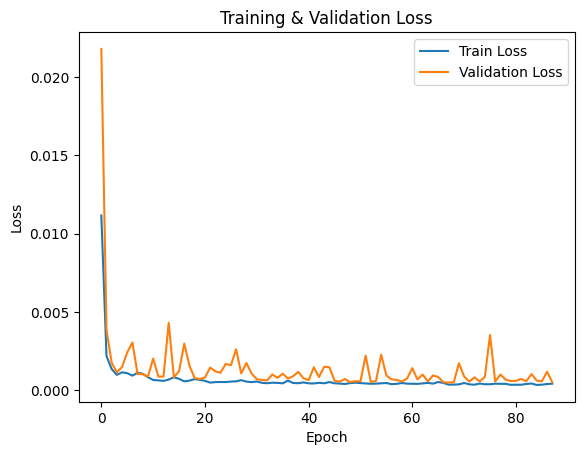

In [88]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')
plt.show()

In [89]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Contoh prediksi dari test_generator
pred_scaled = model.predict(test_generator)

# Inverse scale prediksi dan ground truth
y_pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(test_y[look_back:])

# Metrik evaluasi
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # dalam persen

# Print hasil
print(f"📊 Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")



11/11 [==============================] - 0s 3ms/step
📊 Evaluation Metrics:
MAE  : 55.7519
MAPE : 1.32%


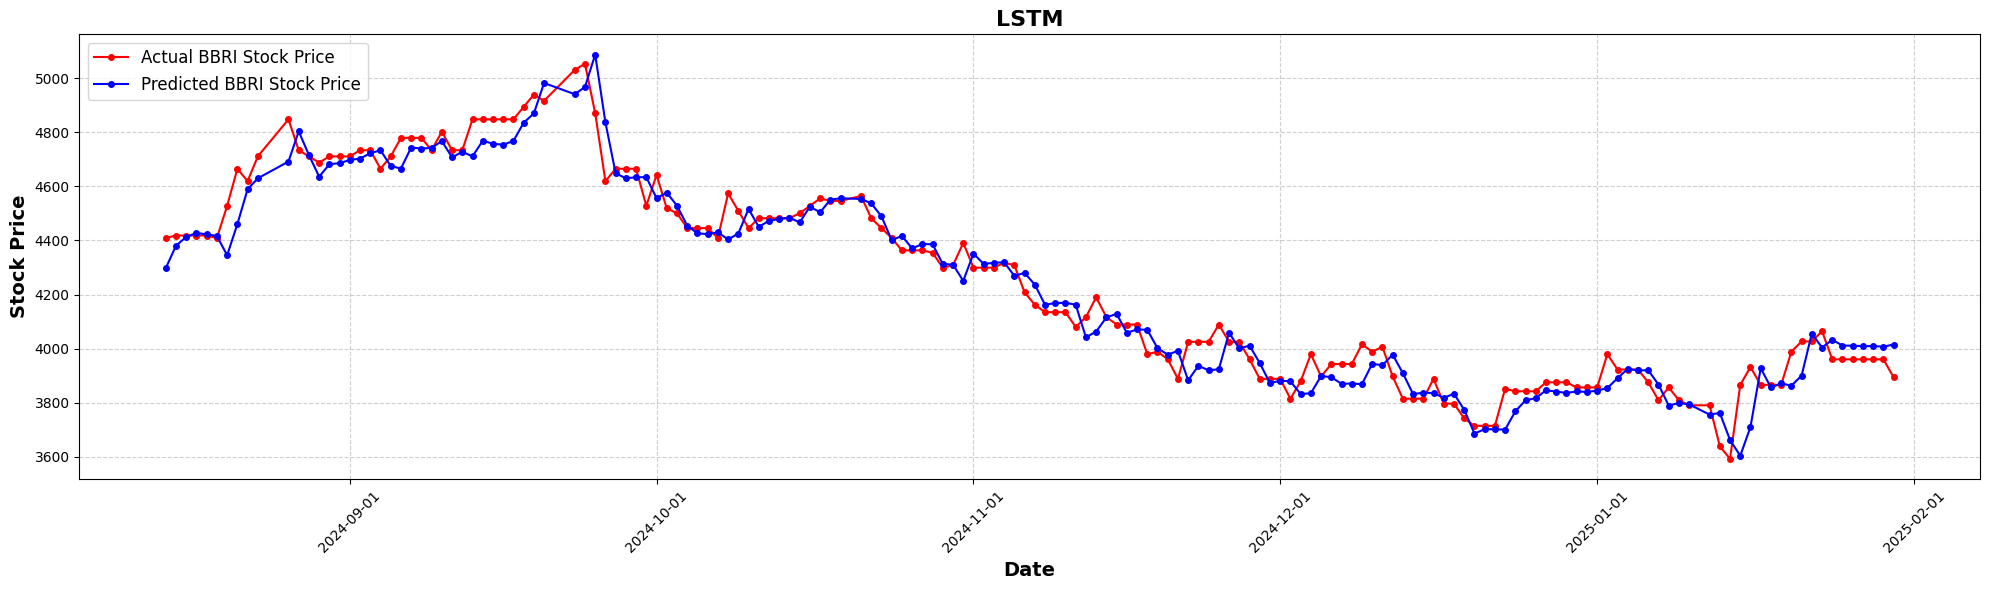

In [90]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Konversi kolom 'Date' ke format datetime jika belum
test_data['Date'] = pd.to_datetime(test_data['Date'])

# Jika kamu menggunakan TimeseriesGenerator dengan look_back, offset perlu disesuaikan
offset = look_back  # Biasanya 20

# Siapkan tanggal yang sesuai (karena TimeseriesGenerator kehilangan look_back pertama)
plot_dates = test_data['Date'][offset:].reset_index(drop=True)

# Buat plot
plt.figure(figsize=(20, 6))

# Real values (y_true sudah di-inverse transform)
plt.plot(plot_dates, y_true, 'o-', color='red',
         linewidth=1.5, markersize=4, label="Actual BBRI Stock Price")

# Predicted values
plt.plot(plot_dates, y_pred, 'o-', color='blue',
         linewidth=1.5, markersize=4, label="Predicted BBRI Stock Price")

# Format sumbu dan tampilan
plt.xlabel("Date", fontsize=14, fontweight='bold')
plt.ylabel("Stock Price", fontsize=14, fontweight='bold')
plt.title("LSTM", fontsize=16, fontweight='bold')

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()


# CNN

In [71]:
import pandas as pd 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten
from keras.optimizers import Adam
import glob
import re

In [72]:
df = pd.read_csv('data_BBRI.csv')
df = df.drop(columns=['Unnamed: 0'])
df

,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Inflasi,mean_comp
0,2019-01-04,2372.937012,2372.937012,2340.519771,2347.003254,14375.400391,0.0282,0.00000
1,2019-01-07,2372.937012,2405.354078,2372.937012,2398.870770,14267.000000,0.0282,0.14310
2,2019-01-08,2385.904053,2385.904053,2353.486983,2372.937260,14083.000000,0.0282,0.00000
3,2019-01-09,2411.837646,2424.804439,2392.387371,2405.354163,14138.000000,0.0282,0.00000
4,2019-01-10,2431.287842,2431.287842,2405.354084,2424.804359,14130.000000,0.0282,0.00000
...,...,...,...,...,...,...,...,...
1831,2025-01-26,3960.211426,4111.436683,3960.211426,4111.436683,16230.900391,0.0076,0.58480
1832,2025-01-27,3960.211426,4111.436683,3960.211426,4111.436683,16164.900391,0.0076,0.58480
1833,2025-01-28,3960.211426,4111.436683,3960.211426,4111.436683,16155.599609,0.0076,0.58480
1834,2025-01-29,3960.211426,4111.436683,3960.211426,4111.436683,15881.200195,0.0076,0.89515


In [73]:
import numpy as np
import random
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Step 1: Set Seed (Reproducibility)
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# Memastikan TensorFlow berjalan secara deterministik
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # Jika menggunakan GPU

In [74]:
train_size = int(0.7 * len(df))
val_size = int(0.2 * len(df))
test_size = len(df) - train_size - val_size  # Sisa untuk test

# Pisahkan data tanpa shuffle
train_data = df.iloc[:train_size].reset_index(drop=True)
val_data = df.iloc[train_size:train_size + val_size].reset_index(drop=True)
test_data = df.iloc[train_size + val_size:].reset_index(drop=True)

In [75]:
from sklearn.preprocessing import MinMaxScaler

# Fitur dan target
feature_cols = ['Stock Open', 'Stock High', 'Stock Low', 'Inflasi', 'Exchange Price','mean_comp']
target_col = 'Stock Price'

# Inisialisasi scaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit hanya ke data train (untuk menghindari leakage)
X_train_scaled = scaler_X.fit_transform(train_data[feature_cols])
X_val_scaled = scaler_X.transform(val_data[feature_cols])
X_test_scaled = scaler_X.transform(test_data[feature_cols])

y_train_scaled = scaler_y.fit_transform(train_data[[target_col]])
y_val_scaled = scaler_y.transform(val_data[[target_col]])
y_test_scaled = scaler_y.transform(test_data[[target_col]])


In [76]:
# reshape ke (samples, time_steps=1, features)
train_X = X_train_scaled
val_X = X_val_scaled
test_X = X_test_scaled

train_y = y_train_scaled
val_y = y_val_scaled
test_y = y_test_scaled


In [77]:
# Conv1D = Lapisan dalam jaringan saraf konvolusional (CNN)

from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from keras.models import Sequential
from keras.layers import Dense, Conv1D, Flatten

look_back = 20
batch_size = 16

train_generator = TimeseriesGenerator(train_X, train_y,
                                      length=look_back, batch_size=batch_size)
val_generator = TimeseriesGenerator(val_X, val_y,
                                    length=look_back, batch_size=batch_size)
test_generator = TimeseriesGenerator(test_X, test_y,
                                     length=look_back, batch_size=batch_size)

# Defining CNN model for time series forecasting
n_filters = 128
kernel_size = 3
n_features = len(feature_cols)
model = Sequential()
model.add(Conv1D(filters=n_filters, kernel_size=kernel_size, activation='relu', input_shape=(look_back, n_features)))
model.add(Flatten())
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,              
    restore_best_weights=True 
)

history = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
80/80 [==============================] - 0s 3ms/step - loss: 0.0350 - val_loss: 0.0043
Epoch 2/100
80/80 [==============================] - 0s 2ms/step - loss: 0.0025 - val_loss: 0.0045
Epoch 3/100
80/80 [==============================] - 0s 2ms/step - loss: 0.0020 - val_loss: 0.0122
Epoch 4/100
80/80 [==============================] - 0s 2ms/step - loss: 0.0025 - val_loss: 0.0036
Epoch 5/100
80/80 [==============================] - 0s 2ms/step - loss: 0.0019 - val_loss: 0.0031
Epoch 6/100
80/80 [==============================] - 0s 2ms/step - loss: 0.0016 - val_loss: 0.0034
Epoch 7/100
80/80 [==============================] - 0s 2ms/step - loss: 0.0029 - val_loss: 0.0058
Epoch 8/100
80/80 [==============================] - 0s 2ms/step - loss: 0.0026 - val_loss: 0.0037
Epoch 9/100
80/80 [==============================] - 0s 2ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 10/100
80/80 [==============================] - 0s 2ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 11/

Epoch 81/100
80/80 [==============================] - 0s 2ms/step - loss: 6.8793e-04 - val_loss: 0.0021
Epoch 82/100
80/80 [==============================] - 0s 2ms/step - loss: 4.6878e-04 - val_loss: 9.6579e-04
Epoch 83/100
80/80 [==============================] - 0s 2ms/step - loss: 7.3146e-04 - val_loss: 0.0014
Epoch 84/100
80/80 [==============================] - 0s 2ms/step - loss: 7.8750e-04 - val_loss: 0.0021
Epoch 85/100
80/80 [==============================] - 0s 2ms/step - loss: 5.4834e-04 - val_loss: 0.0029
Epoch 86/100
80/80 [==============================] - 0s 2ms/step - loss: 7.4849e-04 - val_loss: 0.0020


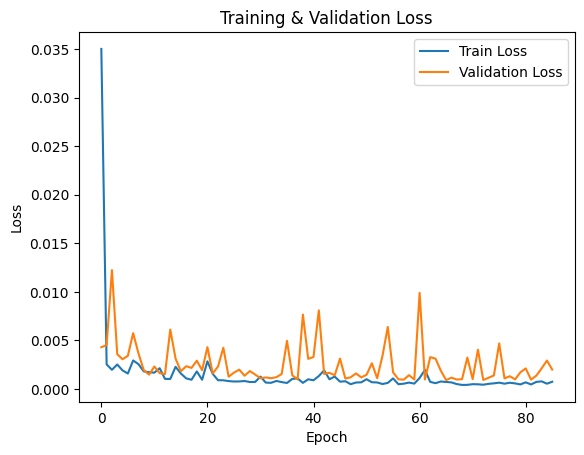

In [78]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')
plt.show()


In [79]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Contoh prediksi dari test_generator
pred_scaled = model.predict(test_generator)

# Inverse scale prediksi dan ground truth
y_pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(test_y[look_back:])

# Metrik evaluasi
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # dalam persen

# Print hasil
print(f"📊 Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")


11/11 [==============================] - 0s 1ms/step
📊 Evaluation Metrics:
MAE  : 73.5451
MAPE : 1.75%


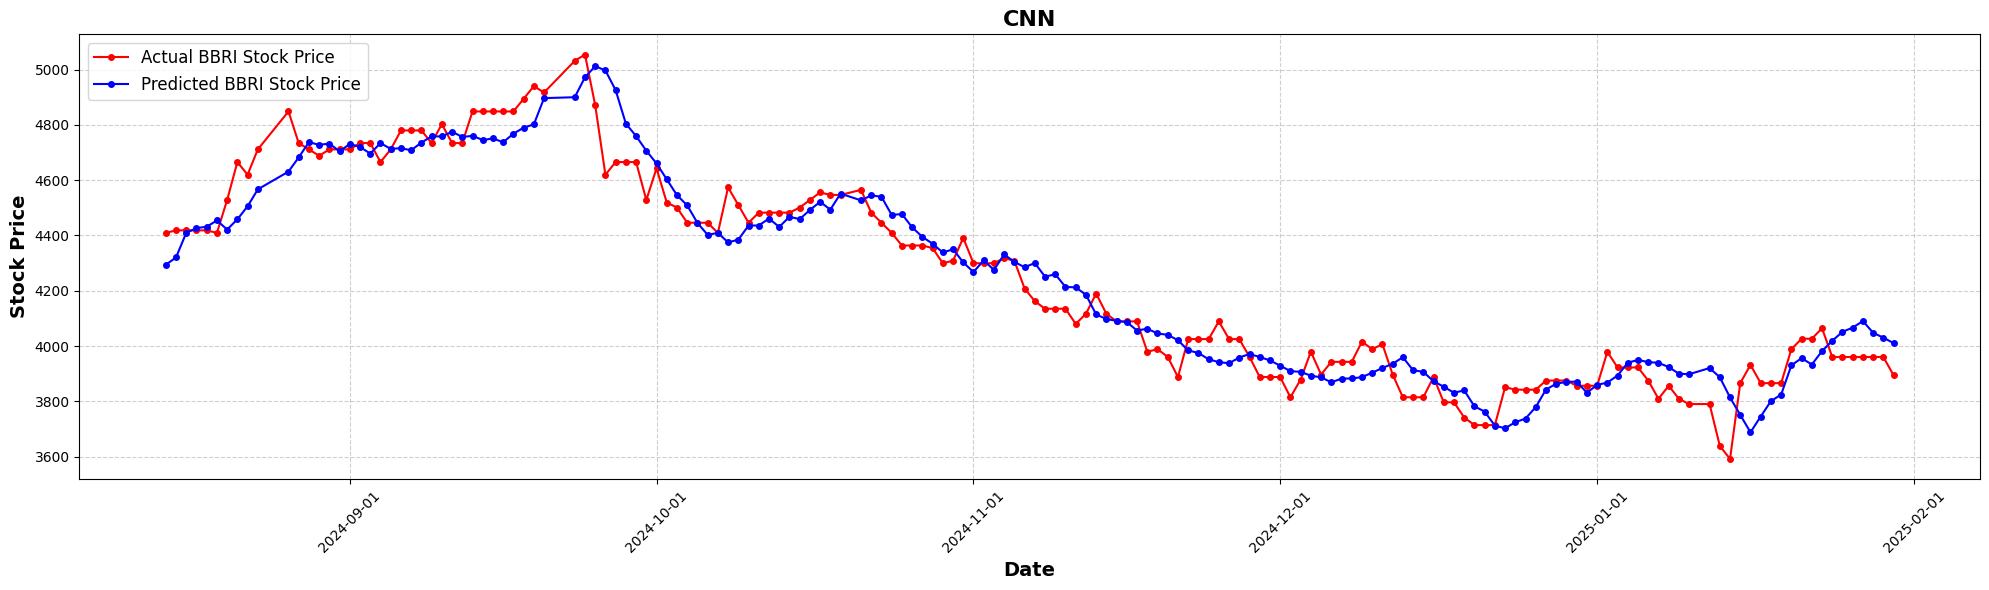

In [80]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

test_data['Date'] = pd.to_datetime(test_data['Date'])

offset = look_back  # Biasanya 20

# Prediksi hasil model sudah di-inverse transform
y_pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(test_y[offset:])

# Siapkan tanggal
plot_dates = test_data['Date'][offset:].reset_index(drop=True)

# Buat plot
plt.figure(figsize=(20, 6))

# Real values (y_true sudah di-inverse transform)
plt.plot(plot_dates, y_true, 'o-', color='red',
         linewidth=1.5, markersize=4, label="Actual BBRI Stock Price")

# Predicted values
plt.plot(plot_dates, y_pred, 'o-', color='blue',
         linewidth=1.5, markersize=4, label="Predicted BBRI Stock Price")

# Format sumbu dan tampilan
plt.xlabel("Date", fontsize=14, fontweight='bold')
plt.ylabel("Stock Price", fontsize=14, fontweight='bold')
plt.title("CNN", fontsize=16, fontweight='bold')

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()


# CNN-LSTM

In [52]:
import pandas as pd 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten, LSTM
from keras.optimizers import Adam
import glob
import re

In [62]:
df = pd.read_csv('data_BBRI.csv')
df = df.drop(columns=['Unnamed: 0'])
df

,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Inflasi,mean_comp
0,2019-01-04,2372.937012,2372.937012,2340.519771,2347.003254,14375.400391,0.0282,0.00000
1,2019-01-07,2372.937012,2405.354078,2372.937012,2398.870770,14267.000000,0.0282,0.14310
2,2019-01-08,2385.904053,2385.904053,2353.486983,2372.937260,14083.000000,0.0282,0.00000
3,2019-01-09,2411.837646,2424.804439,2392.387371,2405.354163,14138.000000,0.0282,0.00000
4,2019-01-10,2431.287842,2431.287842,2405.354084,2424.804359,14130.000000,0.0282,0.00000
...,...,...,...,...,...,...,...,...
1831,2025-01-26,3960.211426,4111.436683,3960.211426,4111.436683,16230.900391,0.0076,0.58480
1832,2025-01-27,3960.211426,4111.436683,3960.211426,4111.436683,16164.900391,0.0076,0.58480
1833,2025-01-28,3960.211426,4111.436683,3960.211426,4111.436683,16155.599609,0.0076,0.58480
1834,2025-01-29,3960.211426,4111.436683,3960.211426,4111.436683,15881.200195,0.0076,0.89515


In [63]:
import numpy as np
import random
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Step 1: Set Seed (Reproducibility)
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# Memastikan TensorFlow berjalan secara deterministik
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # Jika menggunakan GPU

In [64]:
train_size = int(0.7 * len(df))
val_size = int(0.2 * len(df))
test_size = len(df) - train_size - val_size

train_data = df.iloc[:train_size].reset_index(drop=True)
val_data = df.iloc[train_size:train_size + val_size].reset_index(drop=True)
test_data = df.iloc[train_size + val_size:].reset_index(drop=True)


In [65]:
from sklearn.preprocessing import MinMaxScaler

# Fitur dan target
feature_cols = ['Stock Open', 'Stock High', 'Stock Low', 'Inflasi', 'Exchange Price','mean_comp']
target_col = 'Stock Price'

# Inisialisasi scaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit hanya ke data train (untuk menghindari leakage)
X_train_scaled = scaler_X.fit_transform(train_data[feature_cols])
X_val_scaled = scaler_X.transform(val_data[feature_cols])
X_test_scaled = scaler_X.transform(test_data[feature_cols])

y_train_scaled = scaler_y.fit_transform(train_data[[target_col]])
y_val_scaled = scaler_y.transform(val_data[[target_col]])
y_test_scaled = scaler_y.transform(test_data[[target_col]])


In [66]:
# reshape ke (samples, time_steps=1, features)
train_X = X_train_scaled
val_X = X_val_scaled
test_X = X_test_scaled

train_y = y_train_scaled
val_y = y_val_scaled
test_y = y_test_scaled


In [67]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from keras.models import Sequential
from keras.layers import Dense, Conv1D, LSTM, Flatten

look_back = 20
batch_size = 16

train_generator = TimeseriesGenerator(train_X, train_y,
                                      length=look_back, batch_size=batch_size)
val_generator = TimeseriesGenerator(val_X, val_y,
                                    length=look_back, batch_size=batch_size)
test_generator = TimeseriesGenerator(test_X, test_y,
                                     length=look_back, batch_size=batch_size)

# # Defining hybrid CNN-LSTM model for time series forecasting
n_filters = 128
n_features = len(feature_cols)
kernel_size = 3
model = Sequential()
model.add(Conv1D(filters=n_filters, kernel_size=kernel_size, activation='relu',input_shape=(look_back, n_features)))
model.add(LSTM(64, input_shape=(look_back, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,              
    restore_best_weights=True 
)

history = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
80/80 [==============================] - 2s 12ms/step - loss: 0.0119 - val_loss: 0.0059
Epoch 2/100
80/80 [==============================] - 1s 8ms/step - loss: 0.0019 - val_loss: 0.0031
Epoch 3/100
80/80 [==============================] - 1s 8ms/step - loss: 0.0017 - val_loss: 0.0022
Epoch 4/100
80/80 [==============================] - 1s 7ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 5/100
80/80 [==============================] - 1s 8ms/step - loss: 0.0014 - val_loss: 0.0043
Epoch 6/100
80/80 [==============================] - 1s 9ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 7/100
80/80 [==============================] - 1s 8ms/step - loss: 0.0013 - val_loss: 0.0029
Epoch 8/100
80/80 [==============================] - 1s 10ms/step - loss: 0.0016 - val_loss: 0.0021
Epoch 9/100
80/80 [==============================] - 1s 8ms/step - loss: 0.0010 - val_loss: 0.0012
Epoch 10/100
80/80 [==============================] - 1s 8ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 1

Epoch 79/100
80/80 [==============================] - 1s 10ms/step - loss: 4.6132e-04 - val_loss: 7.3827e-04
Epoch 80/100
80/80 [==============================] - 1s 9ms/step - loss: 3.1566e-04 - val_loss: 4.9481e-04
Epoch 81/100
80/80 [==============================] - 1s 8ms/step - loss: 3.1457e-04 - val_loss: 8.7987e-04
Epoch 82/100
80/80 [==============================] - 1s 9ms/step - loss: 3.1488e-04 - val_loss: 0.0011
Epoch 83/100
80/80 [==============================] - 1s 9ms/step - loss: 6.5700e-04 - val_loss: 6.0480e-04
Epoch 84/100
80/80 [==============================] - 1s 8ms/step - loss: 6.8238e-04 - val_loss: 0.0026
Epoch 85/100
80/80 [==============================] - 1s 9ms/step - loss: 3.4975e-04 - val_loss: 8.2566e-04
Epoch 86/100
80/80 [==============================] - 1s 8ms/step - loss: 3.4964e-04 - val_loss: 0.0013
Epoch 87/100
80/80 [==============================] - 1s 9ms/step - loss: 5.2397e-04 - val_loss: 0.0028
Epoch 88/100
80/80 [=======================

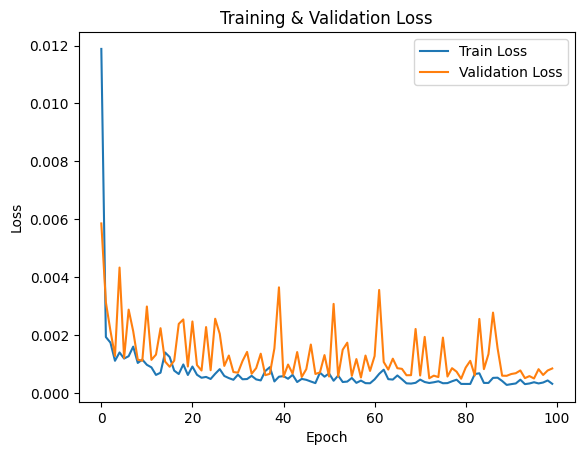

In [68]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')
plt.show()


In [69]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Contoh prediksi dari test_generator
pred_scaled = model.predict(test_generator)

# Inverse scale prediksi dan ground truth
y_pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(test_y[look_back:])

# Metrik evaluasi
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # dalam persen

# Print hasil
print(f"📊 Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")


11/11 [==============================] - 0s 3ms/step
📊 Evaluation Metrics:
MAE  : 57.1387
MAPE : 1.35%


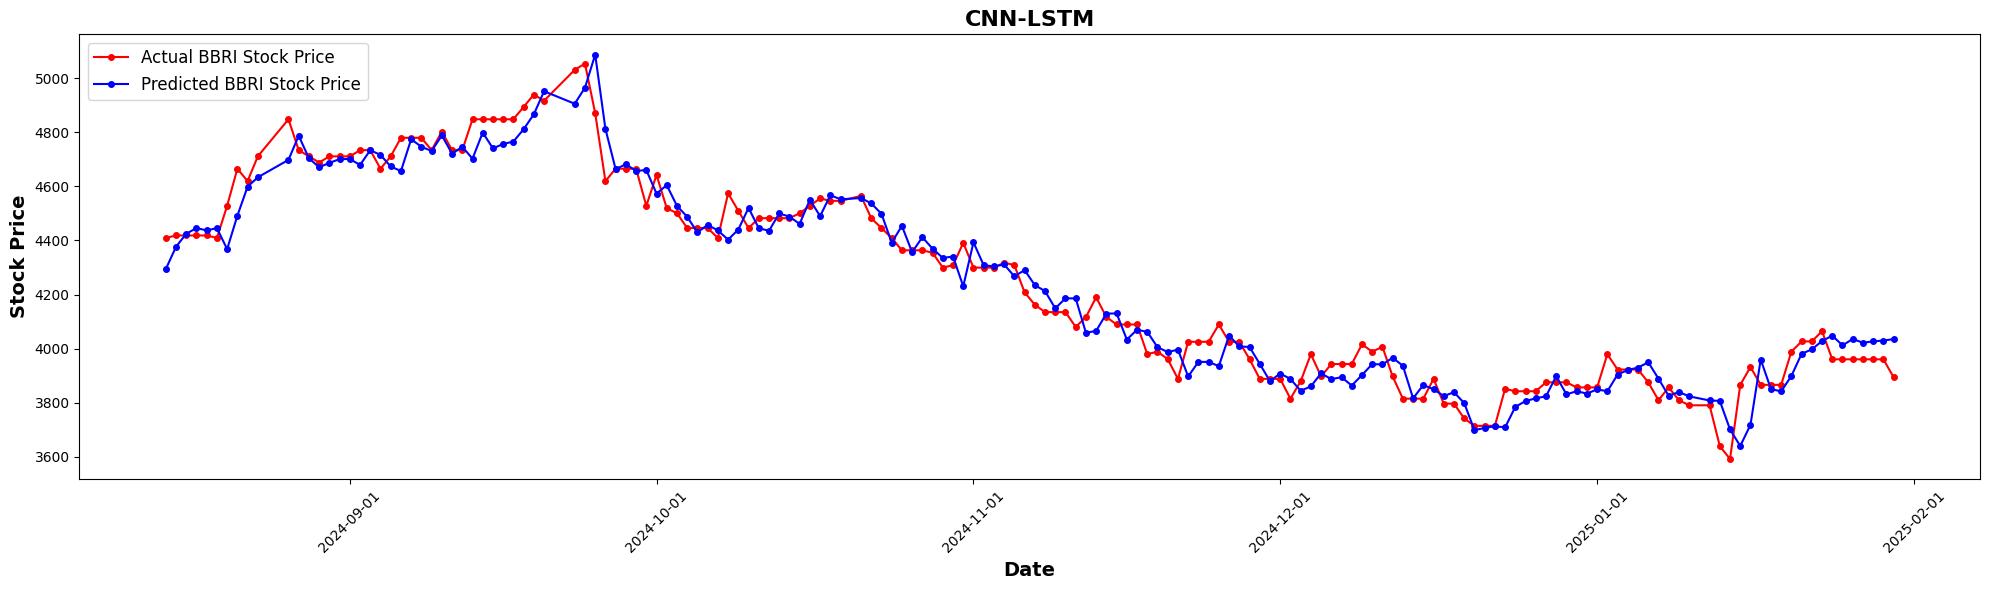

In [70]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Konversi kolom 'Date' ke format datetime jika belum
test_data['Date'] = pd.to_datetime(test_data['Date'])

offset = look_back  # Biasanya 20

# Prediksi hasil model sudah di-inverse transform
y_pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(test_y[offset:])

# Siapkan tanggal yang sesuai (karena TimeseriesGenerator kehilangan look_back pertama)
plot_dates = test_data['Date'][offset:].reset_index(drop=True)

# Buat plot
plt.figure(figsize=(20, 6))

# Real values (y_true sudah di-inverse transform)
plt.plot(plot_dates, y_true, 'o-', color='red',
         linewidth=1.5, markersize=4, label="Actual BBRI Stock Price")

# Predicted values
plt.plot(plot_dates, y_pred, 'o-', color='blue',
         linewidth=1.5, markersize=4, label="Predicted BBRI Stock Price")

# Format sumbu dan tampilan
plt.xlabel("Date", fontsize=14, fontweight='bold')
plt.ylabel("Stock Price", fontsize=14, fontweight='bold')
plt.title("CNN-LSTM", fontsize=16, fontweight='bold')

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

# plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()
